In [6]:
# 📌 Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# 📌 Load Dataset
df = pd.read_csv(r"C:\Users\Deepak\OneDrive\Documents\student data analysis\StudentPerformanceFactors.csv")
print(df.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [10]:
# ==============================
# 🧹 DATA CLEANING
# ==============================

# Remove duplicate rows
df = df.drop_duplicates()

# Handle missing values
# Numerical columns → fill with mean
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print(df.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [11]:
# ==============================
# 🔄 DATA TRANSFORMATION
# ==============================

# Convert categorical variables (optional)
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
print(df.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [12]:
# ==============================
# 📊 BASIC ANALYSIS
# ==============================

print("📌 Dataset Shape:", df.shape)

print("\n📌 Data Info:\n")
df.info()

print("\n📌 Statistical Summary:\n")
print(df.describe())
print(df.head())

📌 Dataset Shape: (6607, 20)

📌 Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6607 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_

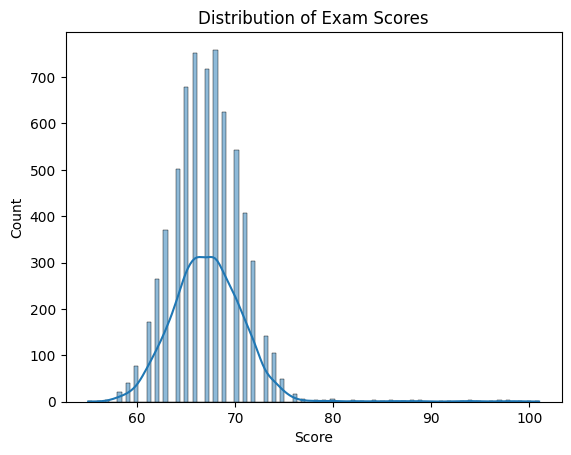

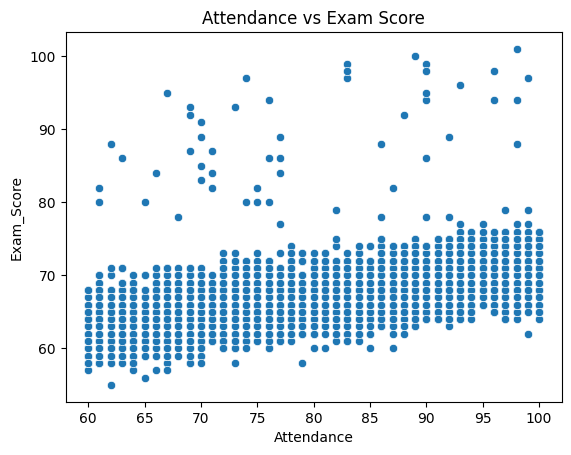

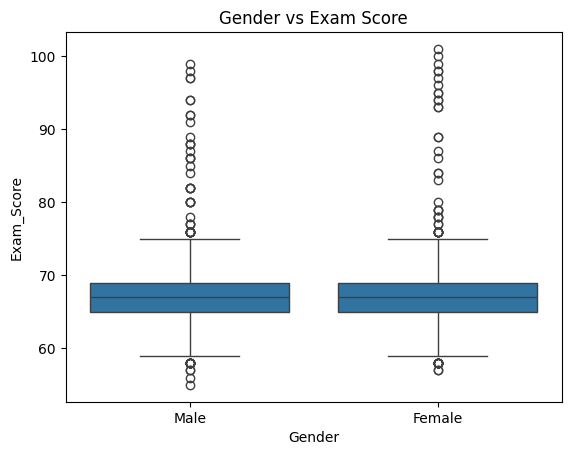

In [13]:
# ==============================
# 📈 EXPLORATORY DATA ANALYSIS
# ==============================

# 1️⃣ Distribution of Scores
if 'Exam_Score' in df.columns:
    plt.figure()
    sns.histplot(df['Exam_Score'], kde=True)
    plt.title("Distribution of Exam Scores")
    plt.xlabel("Score")
    plt.ylabel("Count")
    plt.show()

# 2️⃣ Study Hours vs Score
if 'Study_Hours' in df.columns and 'Exam_Score' in df.columns:
    plt.figure()
    sns.scatterplot(x='Study_Hours', y='Exam_Score', data=df)
    plt.title("Study Hours vs Exam Score")
    plt.show()

# 3️⃣ Attendance vs Score
if 'Attendance' in df.columns and 'Exam_Score' in df.columns:
    plt.figure()
    sns.scatterplot(x='Attendance', y='Exam_Score', data=df)
    plt.title("Attendance vs Exam Score")
    plt.show()

# 4️⃣ Gender-wise Performance
if 'Gender' in df.columns and 'Exam_Score' in df.columns:
    plt.figure()
    sns.boxplot(x='Gender', y='Exam_Score', data=df)
    plt.title("Gender vs Exam Score")
    plt.xticks([0, 1], ['Male', 'Female'])  # Better readability
    plt.show()


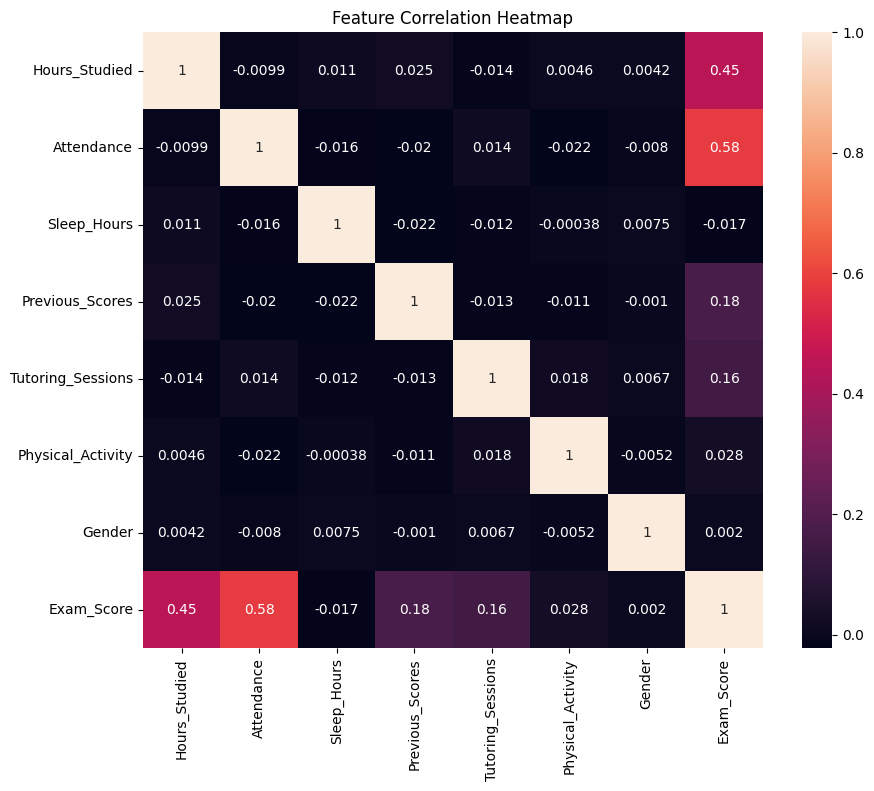

In [14]:
# ==============================
# 🔥 FIXED CORRELATION HEATMAP
# ==============================

# Select only numeric columns (IMPORTANT FIX)
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [15]:
# ==============================
# 💾 SAVE CLEANED DATA
# ==============================

df.to_csv(r"C:\Users\Deepak\OneDrive\Documents\student data analysis\cleaned_student_data.csv", index=False)

print("\n✅ Data Analysis Completed Successfully!")


✅ Data Analysis Completed Successfully!
